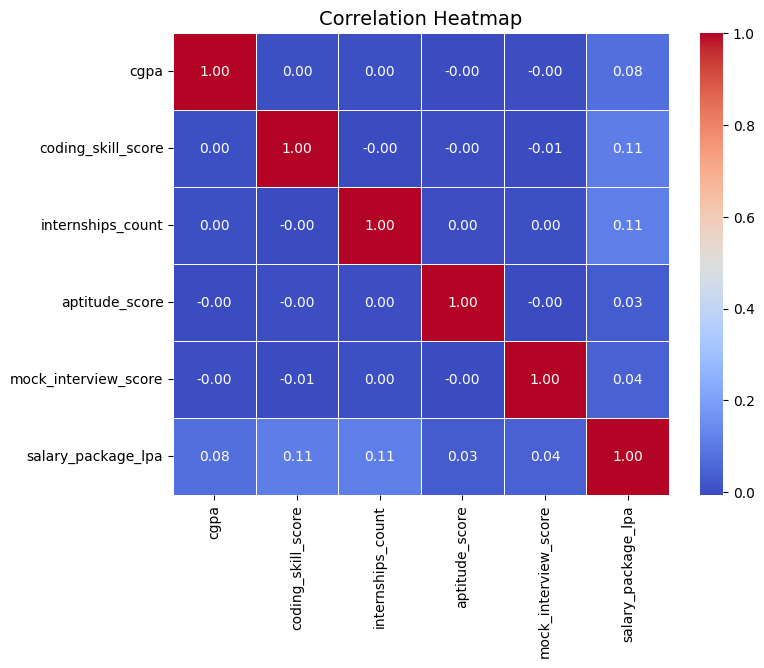

Linear Regression Metrics:
MAE: 0.7980941154694831
MSE: 0.9975094925038905
RMSE: 0.9987539699565107
R2 Score: 0.6062385072254884

Random Forest Metrics:
MAE: 0.8421344840249725
MSE: 1.1069762712100624
RMSE: 1.052129398510498
R2 Score: 0.5630270866661085


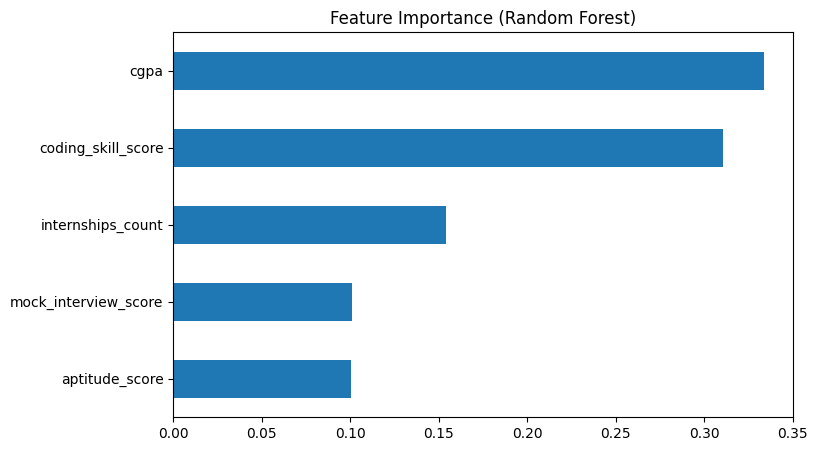

Linear Regression Cross-Validation R2 Scores: [0.61917468 0.60927732 0.61520037 0.6018328  0.59407377]
Average R2: 0.6079117865412842

Models saved successfully.


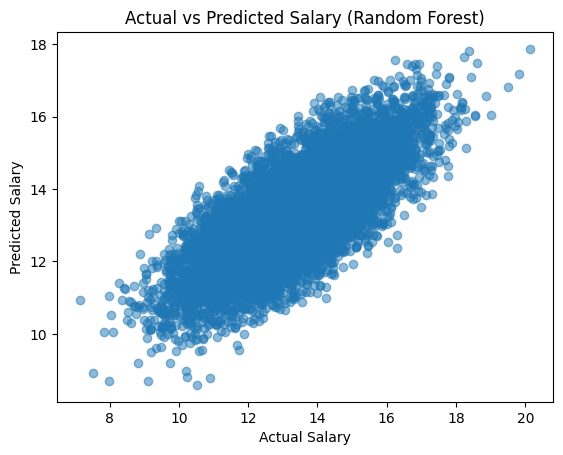

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import plotly.express as px

# Load dataset
df = pd.read_csv(r"C:\Users\mansi\Downloads\student_placement_prediction_dataset_2026.csv")
df.columns = df.columns.str.strip()  

# Encode categorical variables
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Optional: visualize correlation
plt.figure(figsize=(8,6))  
sns.heatmap(df[['cgpa', 'coding_skill_score', 'internships_count', 'aptitude_score', 'mock_interview_score', 'salary_package_lpa']].corr(), annot=True,        
cmap="coolwarm", fmt=".2f", linewidths=0.5, cbar=True) 
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

# Filter only placed students
df = df[df['placement_status'] == 1]

# Drop irrelevant columns
df.drop('student_id', axis=1, inplace=True)

# Feature selection
X = df[['cgpa', 'coding_skill_score', 'internships_count', 'aptitude_score', 'mock_interview_score']]
y = df['salary_package_lpa']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# Evaluation
print("Linear Regression Metrics:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("\nRandom Forest Metrics:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))

# Feature Importance (Random Forest)
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=True).plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance (Random Forest)")
plt.show()

# Cross-validation (Linear Regression)
cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='r2')
print("Linear Regression Cross-Validation R2 Scores:", cv_scores)
print("Average R2:", cv_scores.mean())

# Save models
joblib.dump(lr_model, r"C:\Users\mansi\salary_prediction_lr_model.pkl")
joblib.dump(rf_model, r"C:\Users\mansi\salary_prediction_rf_model.pkl")
print("\nModels saved successfully.")

# Actual vs Predicted plot (Random Forest)
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary (Random Forest)")
plt.show()